# Ridge Regression and RidgeCV Regression

Ridge Regression is a regularized version of Linear Regression that helps reduce **overfitting** by adding an **L2 penalty** to the cost function. Instead of removing features, Ridge Regression shrinks the coefficient values toward zero, resulting in a more stable and generalized model.

We will first build a **Linear Regression** model as a baseline and then compare its performance with **Ridge Regression** and **RidgeCV**. RidgeCV automatically selects the optimal regularization parameter (**alpha**) using Cross-Validation, making model selection easier and more reliable.

Throughout this notebook, we will cover data preprocessing, feature scaling, model training, coefficient shrinkage, hyperparameter tuning, model evaluation, residual analysis, and performance comparison. By the end of this notebook, you will have a clear understanding of when and why Ridge Regression is preferred over ordinary Linear Regression.

In [ ]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI New folder/Algerian_forest_fires_cleaned_dataset.csv')

In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [ ]:
# Remove unnecessary date-related columns
df.drop(columns=["day", "month", "year"], inplace=True)

In [ ]:
# Display the first five rows after removing the columns
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
# Count the number of samples in each class
print("Class Counts:")
print(df["Classes"].value_counts())

print("\nClass Percentage:")
print((df["Classes"].value_counts(normalize=True) * 100).round(2))

Class Counts:
Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

Class Percentage:
Classes
fire             53.91
not fire         41.56
fire              1.65
fire              0.82
not fire          0.82
not fire          0.41
not fire          0.41
not fire          0.41
Name: proportion, dtype: float64


In [ ]:
# Convert the target labels into numerical values
# "Not Fire" → 0
# "Fire" → 1
# Convert labels to lowercase and remove extra spaces before encoding
df["Classes"] = np.where(
    df["Classes"].str.strip().str.lower() == "not fire",
    0,
    1
)

In [ ]:
# Display the unique values after encoding
df["Classes"].unique()

array([0, 1])

In [ ]:
# Divide Dataset into Independent and Dependent Features
# Create the feature matrix (Independent Features)
# Drop the target column because it is what we want to predict
X = df.drop(columns=["FWI"])

# Create the target variable (Dependent Feature)
y = df["FWI"]

In [ ]:
print("Independent Features (X):")
display(X.head())

print("\nDependent Feature (y):")
display(y.head())

Independent Features (X):


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0



Dependent Feature (y):


,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 75% -> Training data
# 25% -> Testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [ ]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (182, 11)
X_test shape  : (61, 11)
y_train shape : (182,)
y_test shape  : (61,)


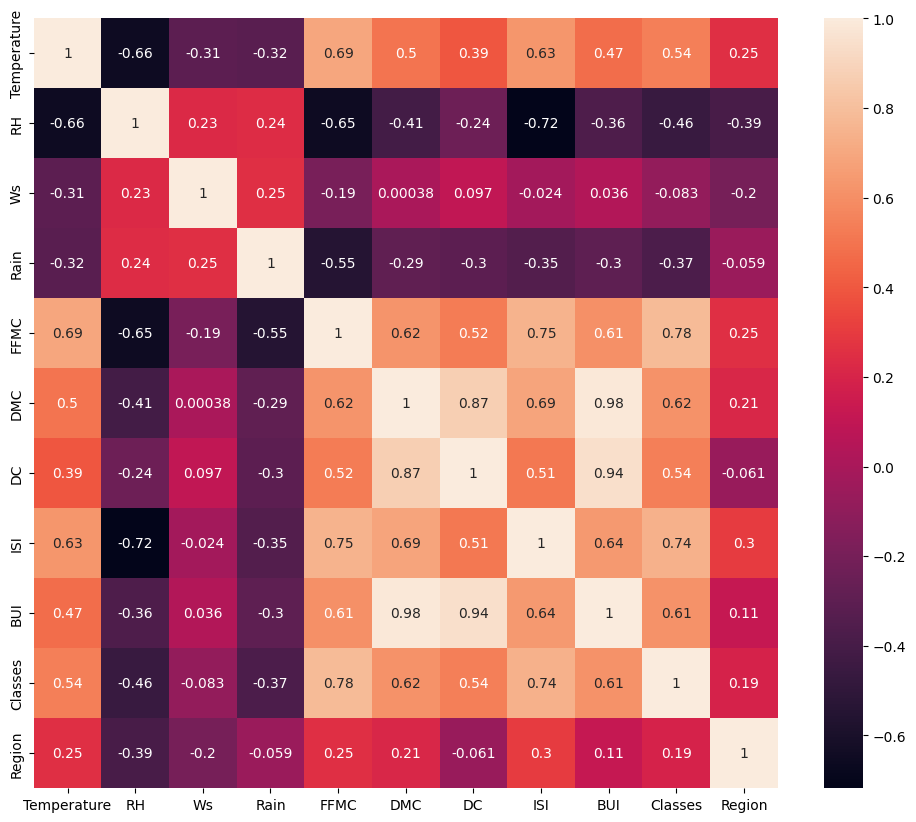

In [ ]:
# Feature Selection Based on Correlation
import seaborn as sns
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
# Detect and Remove Multicollinearity Using Correlation

# Function to identify highly correlated features
def correlation(dataset, threshold):
    """
    Returns a set of feature names whose absolute
    correlation is greater than the specified threshold.
    """

    # Store features to remove
    col_corr = set()

    # Calculate correlation matrix
    corr_matrix = dataset.corr()

    # Compare every pair of features
    for i in range(len(corr_matrix.columns)):
        for j in range(i):

            # Check absolute correlation value
            if abs(corr_matrix.iloc[i, j]) > threshold:

                # Store the feature name
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

In [ ]:
# Find highly correlated features
corr_features = correlation(X_train, threshold=0.85)

print(corr_features)

{'DC', 'BUI'}


This means:

* **DC** has a correlation greater than **0.85** with another feature.
* **BUI** also has a correlation greater than **0.85** with another feature.

These features carry redundant information and can be removed.

**Note:** The exact output may vary depending on the dataset and the chosen threshold.

In [ ]:
# Remove highly correlated features from both datasets

X_train = X_train.drop(columns=corr_features)
X_test = X_test.drop(columns=corr_features)

In [ ]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (182, 9)
Testing Data Shape : (61, 9)


In [ ]:
# Faeture Scaling or Standardization

from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Learn scaling parameters from the training data
# and transform the training features
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same parameters
X_test_scaled = scaler.transform(X_test)

Ridge Regression penalizes coefficients based on their magnitude. Features with larger scales can dominate the penalty, so feature scaling ensures all features contribute equally.

# **Linear Regression Model**

In [ ]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Initialize the Linear Regression model
linreg = LinearRegression()

In [ ]:
# Train the model using the training data
linreg.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Predict the target values for the testing data
y_pred = linreg.predict(X_test_scaled)

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.3f}")
print(f"Mean Squared Error  : {mse:.3f}")
print(f"R² Score            : {r2:.3f}")

Mean Absolute Error : 0.547
Mean Squared Error  : 0.674
R² Score            : 0.985


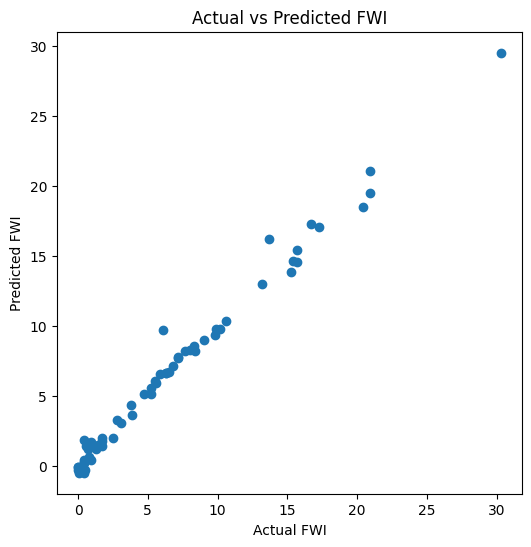

In [ ]:
# Compare actual values with predicted values
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI")

plt.show()

## **Train a Ridge Regression Model**

In [ ]:
from sklearn.linear_model import Ridge

# Initialize the Ridge Regression model
ridge = Ridge()

# Train the model using the training data
ridge.fit(X_train_scaled, y_train)

# Predict the target values for the testing data
ridge_pred = ridge.predict(X_test_scaled)

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, ridge_pred)
mse = mean_squared_error(y_test, ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ridge_pred)

print(f"Mean Absolute Error : {mae:.3f}")
print(f"Mean Squared Error  : {mse:.3f}")
print(f"Root Mean Squared Error : {rmse:.3f}")
print(f"R² Score            : {r2:.3f}")

Mean Absolute Error : 0.564
Mean Squared Error  : 0.695
Root Mean Squared Error : 0.834
R² Score            : 0.984


## **Understanding Coefficient Shrinkage in Ridge Regression**

Ridge Regression adds an **L2 penalty** to the loss function, which discourages the model from assigning very large values to the coefficients.

* The regularization parameter (**a**) controls the amount of shrinkage.
* As **a increases**, the coefficients become smaller.
* Unlike **Lasso Regression**, Ridge Regression **does not make coefficients exactly zero**. Instead, it reduces their magnitude while keeping all features in the model.
* This helps reduce **overfitting**, improves model generalization, and handles **multicollinearity** effectively.

**Note**

* **Linear Regression:** Uses the original coefficient values.
* **Ridge Regression:** Shrinks coefficient values toward zero.
* **Lasso Regression:** Can shrink some coefficients completely to zero, effectively performing feature selection.


In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Ridge Coefficient": ridge.coef_
})

coef_df

,Feature,Ridge Coefficient
0,Temperature,-0.026926
1,RH,-0.205192
2,Ws,0.025544
3,Rain,-0.040692
4,FFMC,-0.785830
5,DMC,3.682867
6,ISI,4.744888
7,Classes,0.434237
8,Region,-0.384662


# **Train a Ridge Regression Model using Cross-Validation (RidgeCV)**

## **What is RidgeCV?**

Previously, we trained a **Ridge Regression** model using the default value of the regularization parameter (`alpha`).

```python
ridge = Ridge()
```

However, choosing the right value of **alpha** is very important.

* A **small alpha** applies very little regularization, which may lead to **overfitting**.
* A **large alpha** applies too much regularization, which may lead to **underfitting**.

Instead of manually trying many alpha values, **RidgeCV** automatically finds the best alpha using **Cross-Validation**.

---

## **What is Alpha in Ridge Regression?**

The **alpha** parameter controls the strength of **L2 Regularization**.

* **Small Alpha** → Less Regularization → More flexible model
* **Large Alpha** → More Regularization → Simpler model

The objective is to find the alpha that gives the **best prediction performance** on unseen data.

---

## **What is Cross-Validation?**

Cross-Validation is a technique used to estimate how well a machine learning model will perform on unseen data.

Instead of splitting the training data only once, it is divided into multiple subsets called **folds**.

For example, if:

```python
cv = 5
```

The training dataset is divided into **5 equal parts**.

The model is trained and validated **5 times**.

| Iteration | Training Data | Validation Data |
| --------- | ------------- | --------------- |
| 1         | Fold 2,3,4,5  | Fold 1          |
| 2         | Fold 1,3,4,5  | Fold 2          |
| 3         | Fold 1,2,4,5  | Fold 3          |
| 4         | Fold 1,2,3,5  | Fold 4          |
| 5         | Fold 1,2,3,4  | Fold 5          |

Finally,

The validation errors from all five folds are averaged.

The alpha value with the **lowest average error** is selected automatically.

---

## **Why do we use RidgeCV?**

Instead of manually trying different alpha values like:

```python
alpha = 0.01

alpha = 0.1

alpha = 1

alpha = 10
```

RidgeCV performs this search automatically.

Benefits:

* Automatically selects the best alpha.
* Produces a better generalized model.
* Reduces manual hyperparameter tuning.
* Saves time and effort.

---

### **Syntax**

```python
RidgeCV(
    alphas=(0.1, 1.0, 10.0),
    *,
    fit_intercept=True,
    scoring=None,
    cv=None,
    gcv_mode=None,
    store_cv_results=False,
    alpha_per_target=False
)
```



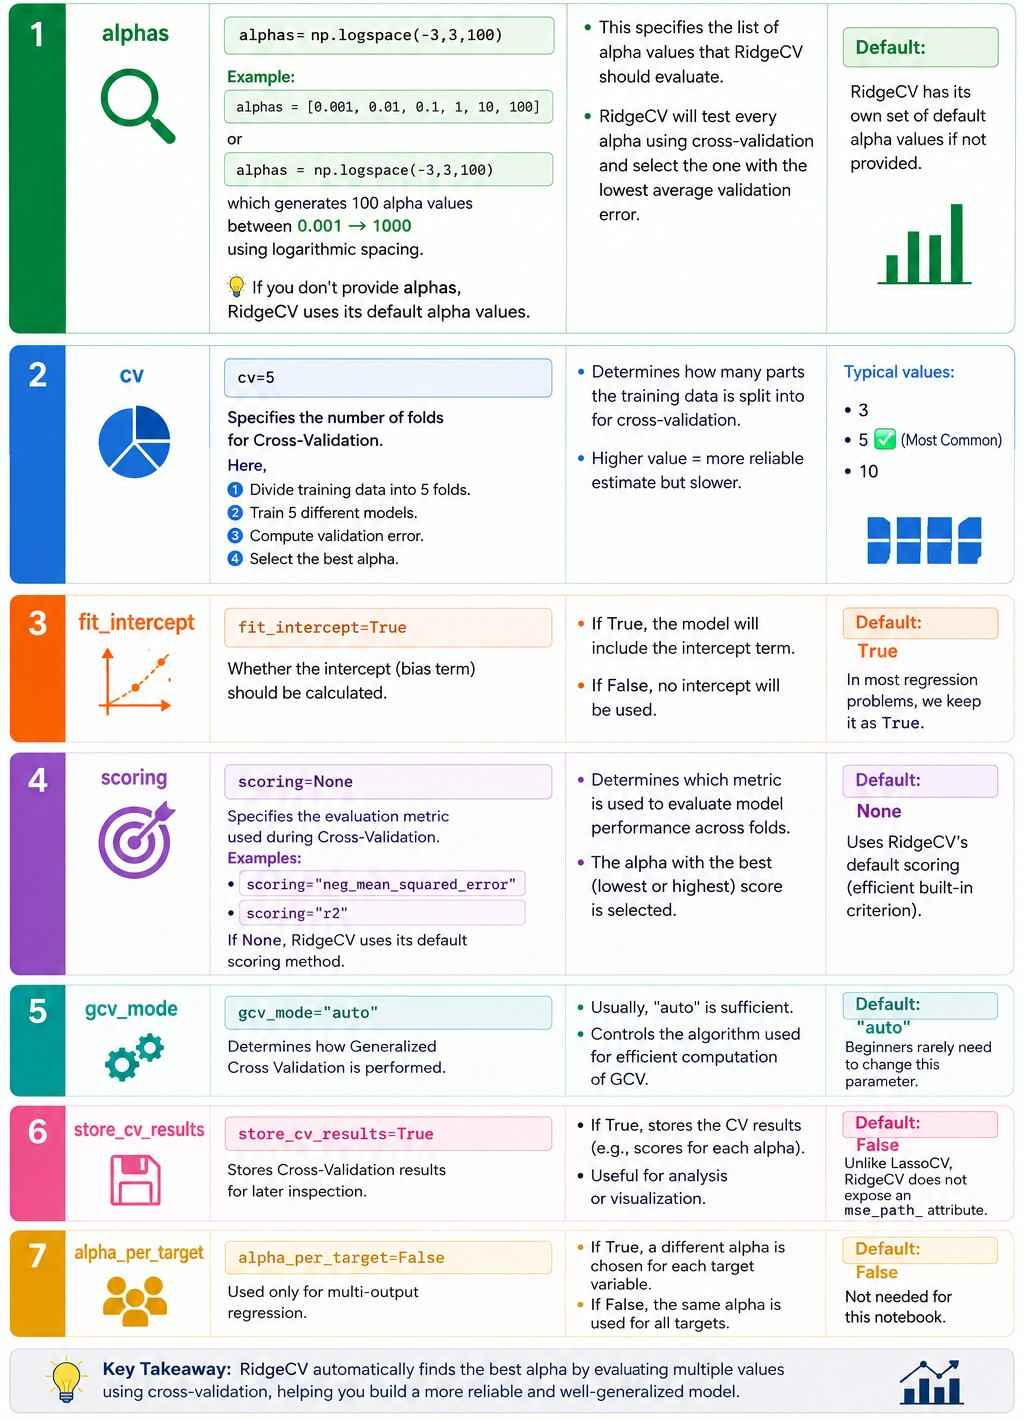



In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Candidate alpha values to evaluate
alphas = np.logspace(-3, 3, 100)

# Initialize RidgeCV
ridgecv = RidgeCV(
    alphas=alphas,
    cv=5
)

# Train the model
ridgecv.fit(X_train_scaled, y_train)

# Predict on the test data
ridgecv_pred = ridgecv.predict(X_test_scaled)

In [ ]:
print(f"Best Alpha Selected: {ridgecv.alpha_:.5f}")

Best Alpha Selected: 4.97702


It simply means that among the 100 alpha values tested, the alpha value 4.97702 produced the lowest average cross-validation error.

For every alpha:

1. Train Ridge Regression.
2. Perform 5-Fold Cross Validation.
3. Compute the average validation error.
4. Compare all errors.
5. Choose the alpha with the lowest error.

For your dataset, the best alpha happened to be: `α = 4.97702`

In [ ]:
import numpy as np

# Generate 100 candidate alpha values ranging from 0.001 to 1000
# using a logarithmic scale.
#
# These alpha values will be evaluated by RidgeCV during
# 5-Fold Cross-Validation to determine the optimal
# regularization strength.
#
# Smaller alpha  → Less regularization
# Larger alpha   → Stronger regularization

alphas = np.logspace(-3, 3, 100)

print(alphas)

[1.00000000e-03 1.14975700e-03 1.32194115e-03 1.51991108e-03
 1.74752840e-03 2.00923300e-03 2.31012970e-03 2.65608778e-03
 3.05385551e-03 3.51119173e-03 4.03701726e-03 4.64158883e-03
 5.33669923e-03 6.13590727e-03 7.05480231e-03 8.11130831e-03
 9.32603347e-03 1.07226722e-02 1.23284674e-02 1.41747416e-02
 1.62975083e-02 1.87381742e-02 2.15443469e-02 2.47707636e-02
 2.84803587e-02 3.27454916e-02 3.76493581e-02 4.32876128e-02
 4.97702356e-02 5.72236766e-02 6.57933225e-02 7.56463328e-02
 8.69749003e-02 1.00000000e-01 1.14975700e-01 1.32194115e-01
 1.51991108e-01 1.74752840e-01 2.00923300e-01 2.31012970e-01
 2.65608778e-01 3.05385551e-01 3.51119173e-01 4.03701726e-01
 4.64158883e-01 5.33669923e-01 6.13590727e-01 7.05480231e-01
 8.11130831e-01 9.32603347e-01 1.07226722e+00 1.23284674e+00
 1.41747416e+00 1.62975083e+00 1.87381742e+00 2.15443469e+00
 2.47707636e+00 2.84803587e+00 3.27454916e+00 3.76493581e+00
 4.32876128e+00 4.97702356e+00 5.72236766e+00 6.57933225e+00
 7.56463328e+00 8.697490

These are generated automatically on a logarithmic scale.

With 100 values, one of those happens to be approximately 4.97702.

In [ ]:
# Can verify it
print(ridgecv.alpha_)
print(ridgecv.alpha_ in alphas)

4.9770235643321135
True


This confirms that RidgeCV selected one of the candidate alpha values you provided.

RidgeCV evaluated 100 different alpha values using 5-Fold Cross Validation. For each alpha, the model calculated the average validation error. After comparing all the results, RidgeCV selected α = 4.97702 because it produced the lowest average cross-validation error, making it the optimal regularization strength for this dataset.

In [ ]:
# Evaluate the Model

mae = mean_absolute_error(y_test, ridgecv_pred)
mse = mean_squared_error(y_test, ridgecv_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ridgecv_pred)

print(f"Mean Absolute Error      : {mae:.3f}")
print(f"Mean Squared Error       : {mse:.3f}")
print(f"Root Mean Squared Error  : {rmse:.3f}")
print(f"R² Score                 : {r2:.3f}")

Mean Absolute Error      : 0.654
Mean Squared Error       : 0.814
Root Mean Squared Error  : 0.902
R² Score                 : 0.982


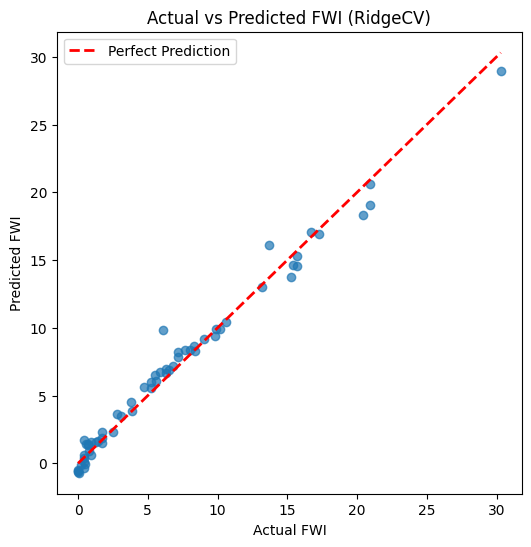

In [ ]:
# Visualize the Predictions

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    ridgecv_pred,
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (RidgeCV)")
plt.legend()

plt.show()



## **Observations**

* Each blue point represents one sample from the **test dataset**.
* The **x-axis** shows the **actual Fire Weather Index (FWI)**, while the **y-axis** shows the **predicted FWI** generated by the RidgeCV model.
* The red dashed line represents **perfect predictions**, where the predicted value is exactly equal to the actual value.
* Most of the data points lie **very close to the red dashed line**, indicating that the RidgeCV model predicts the Fire Weather Index with high accuracy.
* A few points are slightly above or below the reference line, showing **small prediction errors**, which are expected in real-world datasets.
* There are no major outliers or widely scattered points, suggesting that the model generalizes well on the unseen test data.
* The close alignment of the points with the reference line is consistent with the model's **high R² Score** and **low error metrics (MAE, RMSE)** obtained during evaluation.
* Overall, the scatter plot indicates that the **RidgeCV model provides a good fit** for this dataset and is capable of making reliable predictions.

---

## **Conclusion**

> The RidgeCV model successfully captures the relationship between the input features and the Fire Weather Index (FWI). Since most predicted values closely match the actual values, the model demonstrates strong predictive performance and good generalization on the test dataset.


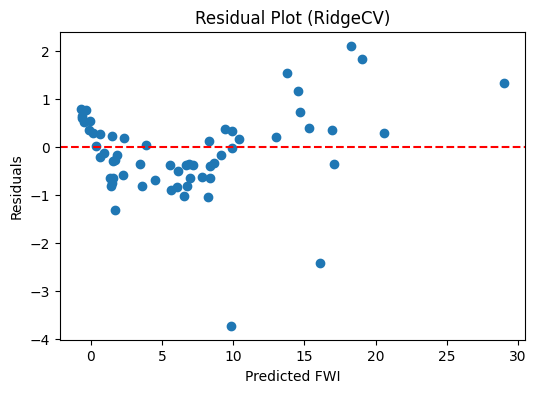

In [ ]:
# Calculate residuals
residuals = y_test - ridgecv_pred

# Residual Plot
plt.figure(figsize=(6,4))

plt.scatter(ridgecv_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted FWI")
plt.ylabel("Residuals")
plt.title("Residual Plot (RidgeCV)")

plt.show()

A residual plot shows the difference between the actual values and the predicted values.

* Residual = Actual Value - Predicted Value
* A good regression model produces residuals that are randomly scattered around the zero line.
* Random scatter indicates that the model has captured the underlying relationship well.
* Any visible pattern or curve may indicate that the model is missing important information or assumptions are violated.

In [ ]:
# Compare feature coefficients of Ridge and RidgeCV

print(f"Ridge Intercept   : {ridge.intercept_:.4f}")
print(f"RidgeCV Intercept : {ridgecv.intercept_:.4f}")

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Ridge Coefficient": ridge.coef_,
    "RidgeCV Coefficient": ridgecv.coef_
})

coef_df

Ridge Intercept   : 7.1560
RidgeCV Intercept : 7.1560


,Feature,Ridge Coefficient,RidgeCV Coefficient
0,Temperature,-0.026926,0.009508
1,RH,-0.205192,-0.303539
2,Ws,0.025544,0.089080
3,Rain,-0.040692,-0.038669
4,FFMC,-0.785830,-0.646408
5,DMC,3.682867,3.616484
6,ISI,4.744888,4.417243
7,Classes,0.434237,0.533154
8,Region,-0.384662,-0.354571


In [ ]:
# Model Performance Comparison

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "RidgeCV"],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, ridgecv_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, ridgecv_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, ridgecv_pred))
    ],
    "R² Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, ridgecv_pred)
    ]
})

comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.546824,0.674277,0.821144,0.984766
1,Ridge Regression,0.564231,0.694920,0.833619,0.984299
2,RidgeCV,0.653604,0.813626,0.902012,0.981617


By comparing MAE, MSE, RMSE, and R² Score, we can determine whether regularization improves the model's generalization performance.

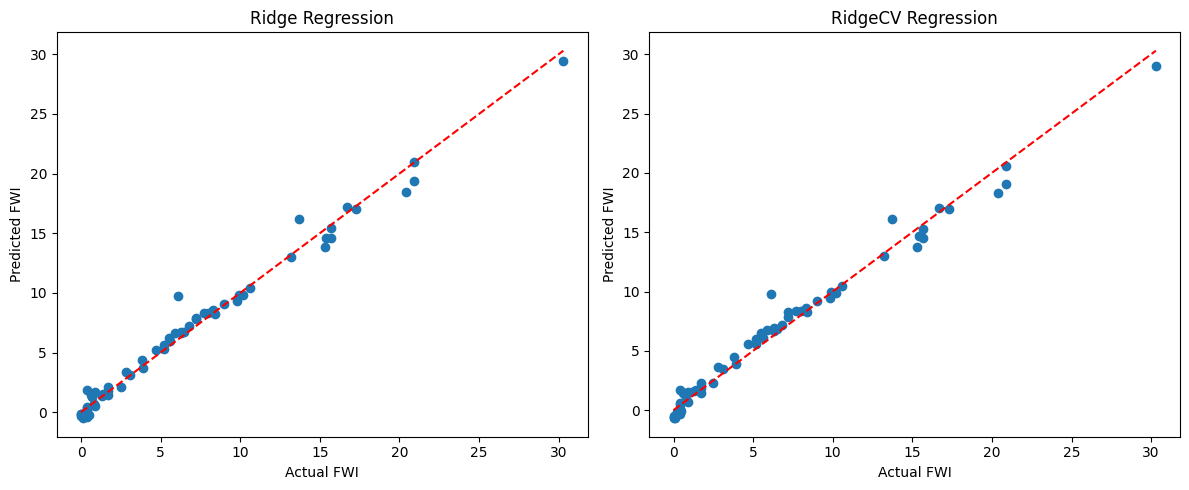

In [ ]:
plt.figure(figsize=(12,5))

# Ridge
plt.subplot(1,2,1)

plt.scatter(y_test, ridge_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Ridge Regression")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

# RidgeCV
plt.subplot(1,2,2)

plt.scatter(y_test, ridgecv_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("RidgeCV Regression")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

plt.tight_layout()
plt.show()

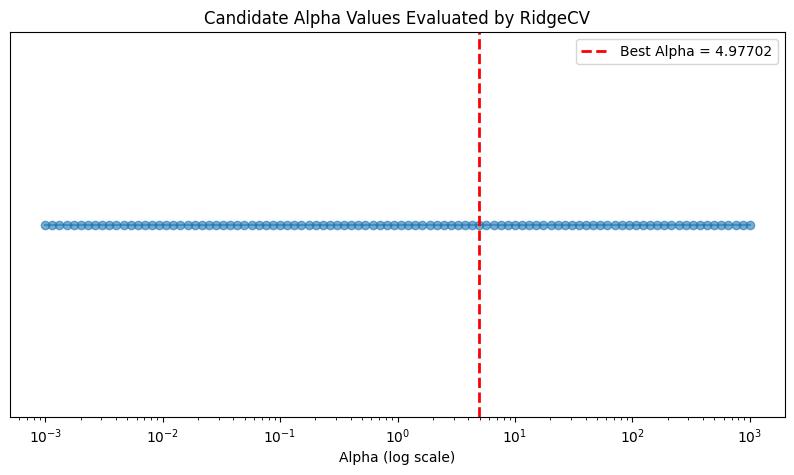

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(alphas, np.zeros_like(alphas), 'o-', alpha=0.6)

plt.axvline(
    ridgecv.alpha_,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Best Alpha = {ridgecv.alpha_:.5f}'
)

plt.xscale("log")

plt.xlabel("Alpha (log scale)")
plt.yticks([])

plt.title("Candidate Alpha Values Evaluated by RidgeCV")

plt.legend()

plt.show()

### **Observations**

* The x-axis displays the **candidate alpha values** evaluated by **RidgeCV** on a **logarithmic scale**.
* Each blue dot represents **one candidate alpha value** tested during **5-Fold Cross-Validation**.
* The red dashed vertical line indicates the **optimal alpha value** selected by RidgeCV.
* In this experiment, RidgeCV selected **α = 4.97702** because it produced the **lowest average cross-validation error** among all the tested alpha values.
* The logarithmic scale allows RidgeCV to efficiently search across a wide range of alpha values, from **0.001** to **1000**, without testing every possible value.
* Smaller alpha values correspond to **weaker regularization**, while larger alpha values correspond to **stronger regularization**.
* After identifying the optimal alpha, RidgeCV automatically trains the final Ridge Regression model using **α = 4.97702**.


 **Note:** Unlike `LassoCV`, `RidgeCV` does not expose the validation error (`mse_path_`) for each candidate alpha. Therefore, we cannot plot the Cross-Validation Error vs. Alpha curve. This visualization only illustrates the range of candidate alpha values evaluated and highlights the optimal alpha selected by RidgeCV.


**Using `np.logspace()` is not mandatory**. It's a **recommended best practice**, especially for hyperparameter tuning.

### **Option 1: Use `np.logspace()` (Recommended)**

```python
alphas = np.logspace(-3, 3, 100)
```

This generates alpha values ranging from **0.001 to 1000** on a **logarithmic scale**.

Why is this recommended?

* Alpha can vary over several orders of magnitude.
* Logarithmic spacing lets the model efficiently explore both **very small** and **very large** alpha values.
* This is the approach commonly used in machine learning libraries, research papers, and professional projects.

---

### **Option 2: Provide Your Own Alpha Values**

You can manually specify the alpha values:

```python
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
```

or

```python
alphas = [0.1, 0.5, 1, 2, 5, 10]
```

Then:

```python
ridgecv = RidgeCV(
    alphas=alphas,
    cv=5
)
```

---

### **Option 3: Don't Specify Any Alpha Values**

```python
ridgecv = RidgeCV(cv=5)
```

This also works.

In this case, **scikit-learn uses its own default alpha values** internally.



### **During Model Development (Real World)**

When a data scientist is building a model, they usually **don't know the best alpha**.

So they define a **search space**.

For example:

```python
alphas = np.logspace(-4, 4, 100)

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5
)
```

or

```python
lasso_cv = LassoCV(
    alphas=alphas,
    cv=5
)
```

This is a very common practice.

---

### **Why use `logspace` instead of `linspace`?**

Suppose the best alpha could be

```text
0.0001
0.001
0.01
0.1
1
10
100
1000
```

Notice how alpha changes by **multiplication**, not by addition.

If you use

```python
np.linspace(0.001,1000,100)
```

you'll get

```text
0.001
10.10
20.20
30.30
...
```

You'll completely miss:

* 0.01
* 0.1
* 0.5
* 2
* 5

These values are often where the best alpha lies.

That's why **logarithmic spacing** is preferred.

---

### **In Production**

Suppose RidgeCV finds

```text
Best Alpha = 4.977
```

You **do not** keep using RidgeCV every time users make predictions.

Instead, you train the final model once.

```python
ridge = Ridge(alpha=4.977)

ridge.fit(X_train_scaled, y_train)
```

Then save it.

```python
import joblib

joblib.dump(ridge, "ridge_model.pkl")
```

During prediction:

```python
model = joblib.load("ridge_model.pkl")

prediction = model.predict(new_data)
```

Notice:

* **No Cross Validation**

* **No logspace**

* **No searching**

The tuning phase happens **offline** during model development.

---

### **What happens in large companies?**

Companies usually don't write

```python
np.logspace(...)
```

everywhere.

Instead they use hyperparameter tuning frameworks like:

* GridSearchCV
* RandomizedSearchCV
* Optuna
* Hyperopt
* Ray Tune

Example:

```python
param_grid = {
    "alpha": np.logspace(-4,4,100)
}

GridSearchCV(
    Ridge(),
    param_grid,
    cv=5
)
```

Notice they're **still using `logspace`**.





> "Companies usually don't write `np.logspace(...)` everywhere."

They **don't usually use `RidgeCV` or `LassoCV` directly** for hyperparameter tuning. Instead, they use more general hyperparameter optimization tools such as `GridSearchCV`, `RandomizedSearchCV`, or Optuna.

However, **they still need to define the search space**, and `np.logspace()` is one of the most common ways to define it.

## **Beginner Workflow**

```python
alphas = np.logspace(-3, 3, 100)

ridgecv = RidgeCV(
    alphas=alphas,
    cv=5
)

ridgecv.fit(X_train_scaled, y_train)
```

Here, `RidgeCV` automatically loops through every alpha in `alphas`.

---

## Real-World Workflow

Instead of `RidgeCV`, many teams use `GridSearchCV`.

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
import numpy as np

# Candidate alpha values
alphas = np.logspace(-3, 3, 100)

# Define parameter grid
param_grid = {
    "alpha": alphas
}

# Grid Search
grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train_scaled, y_train)

print("Best Alpha:", grid.best_params_)
```

Here, `GridSearchCV` tries:

```text
alpha = 0.001
alpha = 0.00115
alpha = 0.00132
...
alpha = 4.977
...
alpha = 1000
```

using **5-fold cross-validation**, just like `RidgeCV`.

---

## Why use GridSearchCV instead of RidgeCV?

Because in real projects, you usually tune **more than one parameter**.

For example:

```python
param_grid = {
    "alpha": np.logspace(-3, 3, 100),
    "solver": ["auto", "svd", "cholesky"],
    "fit_intercept": [True, False]
}
```

Now GridSearchCV evaluates combinations such as:

| Alpha | Solver   | Fit Intercept |
| ----- | -------- | ------------- |
| 0.001 | auto     | True          |
| 0.001 | auto     | False         |
| 0.001 | svd      | True          |
| ...   | ...      | ...           |
| 4.977 | cholesky | False         |

`RidgeCV` can only optimize **alpha**, whereas `GridSearchCV` can optimize **multiple hyperparameters at once**.

---

## What about Optuna?

Companies increasingly use libraries like Optuna because they **don't test every possible value**.

Instead of checking all 100 alpha values, Optuna intelligently searches promising regions.

Example:

```python
def objective(trial):
    alpha = trial.suggest_float(
        "alpha",
        1e-3,
        1e3,
        log=True
    )

    model = Ridge(alpha=alpha)
```

Notice the important part:

```python
log=True
```

This tells Optuna to search on a **logarithmic scale**, just like `np.logspace()`.
